In [1]:
import numpy as truenp

import matplotlib.pyplot as plt
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    circle,
    spider,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy 

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from algos import PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
!nvidia-smi

Sun Apr  5 17:35:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             63W /  300W |   11905MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [19]:
wvl0 = 0.625
wvls = list(truenp.linspace(0.55, 0.725, 25))
npix = 1024
fov = 128
diam = 3000
pupil_dx = diam / npix 
focal_dx = 3.76
efl = 45975.0

x, y = make_xy_grid(shape=npix, dx=pupil_dx)
r, t = cart_to_polar(x, y)

pupil = circle(radius=diam / 2, r=r)

In [49]:
coords = PSDUtils.coord_arrays(dims=(npix, npix), dx=pupil_dx / 1e3)
psd = PSDUtils.abc_psd(coords=coords, a=1, b=0.1, c=2.8, rms=30, rms_scaling=True)
opd_truth = np.array(PSDUtils.create_map(coords, psd, rms=30, seed=727).map)
opd_truth = np.zeros_like(opd_truth)

PSD now scaled to RMS.


([], [])

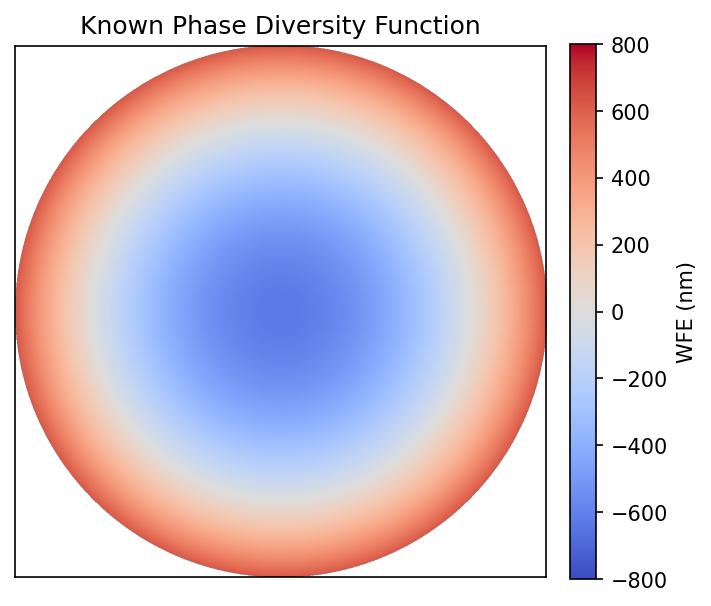

In [61]:
data = copy.copy(opd_truth)
data[~pupil] = np.nan

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(data.get(), vmin=-800, vmax=800, cmap='coolwarm')
plt.colorbar(pad=0.04, fraction=0.046, label='WFE (nm)')
plt.title('Known Phase Diversity Function')
plt.xticks([])
plt.yticks([])

In [57]:
r_norm = r / (diam / 2)
nms = [noll_to_nm(i) for i in range(2, 30)]
zernikes = list(zernike_nm_seq(nms, r_norm, t, norm=True))

defocus_vals = [-2, 0, 2]
divs = [zernikes[3] * defocus_val * wvl0 * 1e3 / np.sqrt(12) for defocus_val in defocus_vals]

opd_truth = zernikes[2] * 2 * wvl0 * 1e3 / np.sqrt(12)

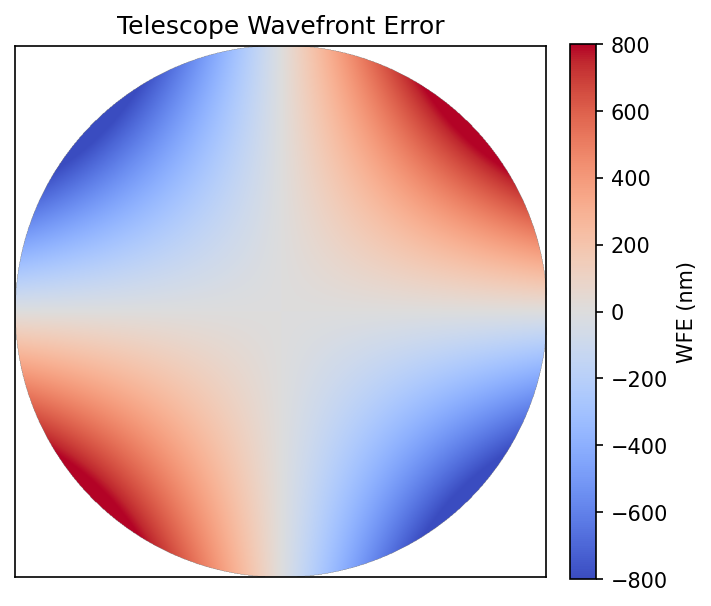

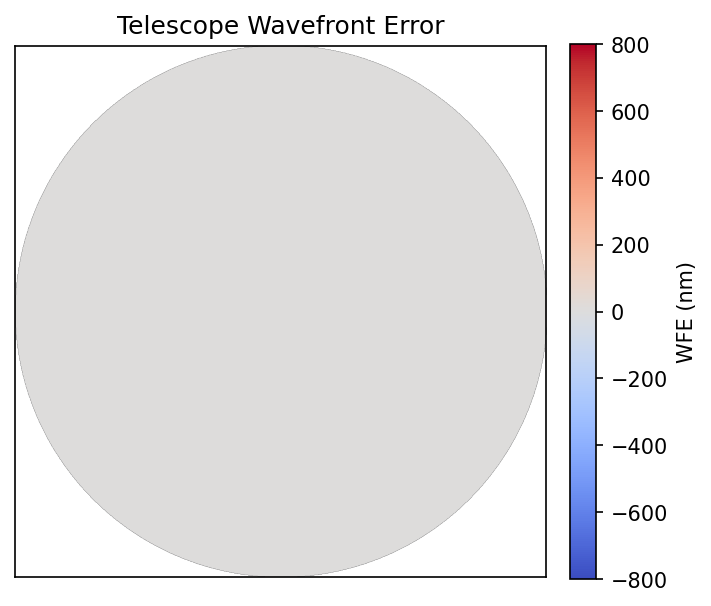

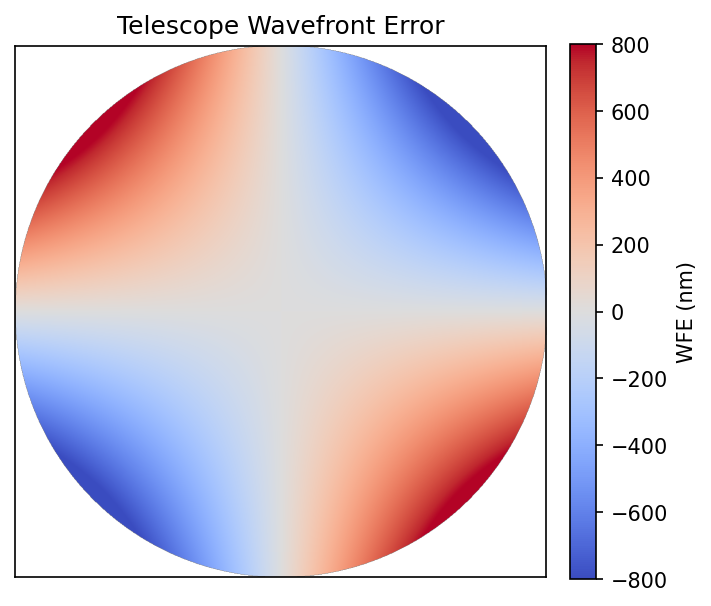

In [55]:
for div, defocus_val in zip(divs, defocus_vals):
    data = copy.copy(div)
    data[~pupil] = np.nan

    plt.figure(figsize=(5, 5), dpi=150)
    plt.imshow(data.get(), vmin=-800, vmax=800, cmap='coolwarm')
    plt.colorbar(pad=0.04, fraction=0.046, label='WFE (nm)')
    plt.title('Telescope Wavefront Error')
    plt.xticks([])
    plt.yticks([])

<Figure size 1500x400 with 0 Axes>

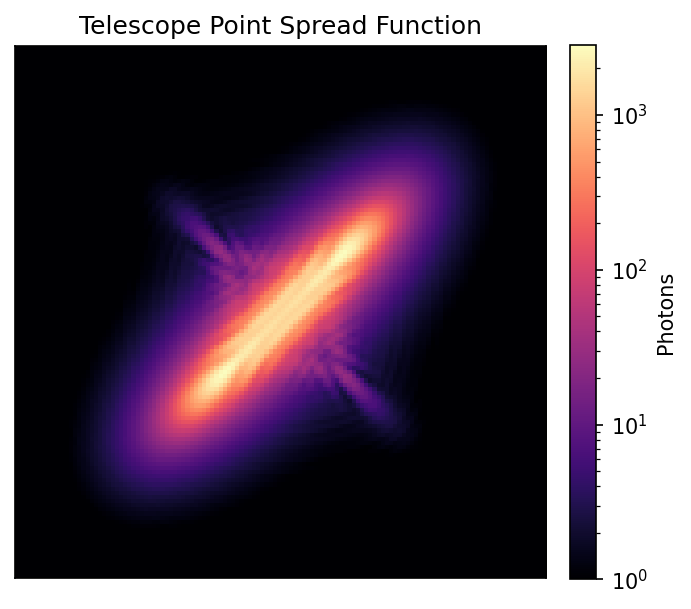

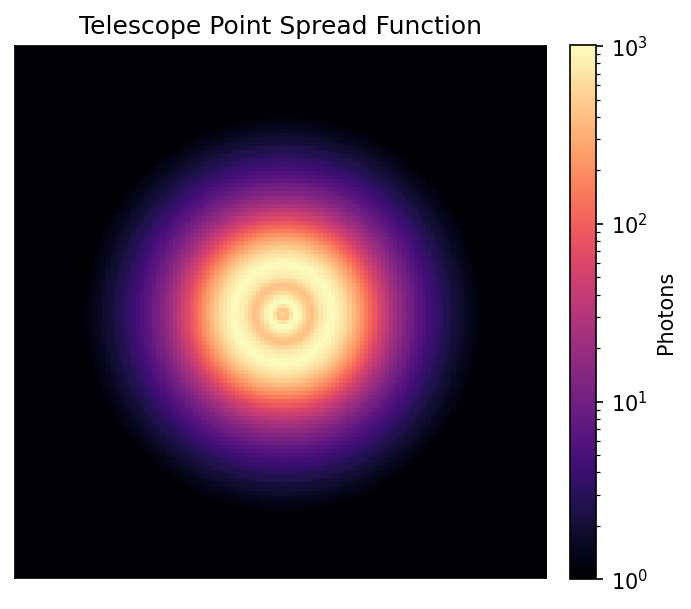

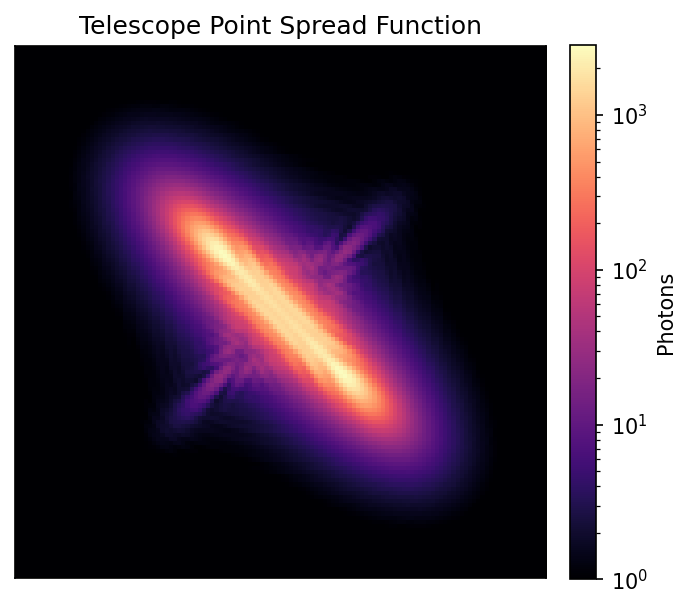

In [58]:
noise = 0

models = [model(wvls=wvls, amp=pupil, opd=opd_truth, div=div, efl=efl, psf=np.zeros((fov, fov)), 
             pupil_dx=pupil_dx, focal_dx=focal_dx, mask=np.ones((fov, fov)).astype('bool'), error=gain_invariant_error) for div in divs]

for m in models:
    m.update()

psfs = [m.I + np.random.normal(loc=0., scale=noise, size=(fov, fov)) for m in models]
for psf in psfs:
    psf[psf < 0] = 0

plt.figure(figsize=(15, 4))
for i, psf in enumerate(psfs):
    plt.figure(figsize=(5, 5), dpi=150)
    plt.imshow(psf.get(), norm='log', cmap='magma', vmin=1)
    plt.colorbar(pad=0.04, fraction=0.046, label='Photons')   
    plt.xticks([])
    plt.yticks([])
    plt.title('Telescope Point Spread Function') 

148600.1102551691


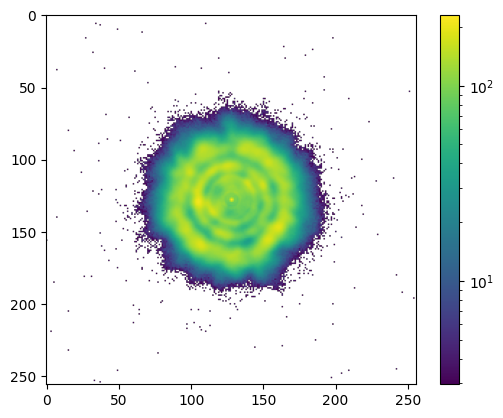

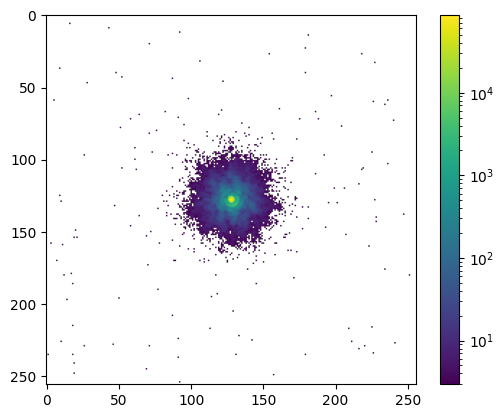

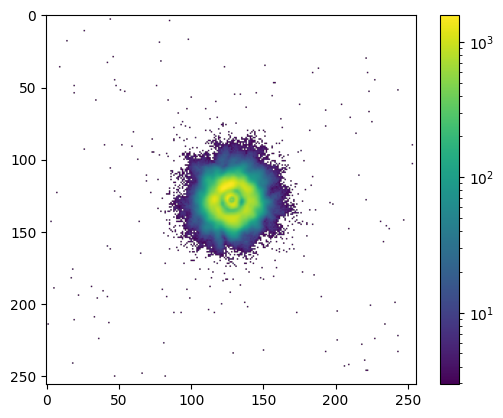

In [ ]:
snr_thresh = 5
noise_lvl = np.std(psfs[1][:30, :30])

for psf in psfs:
    psf[psf < noise_lvl * snr_thresh] = 0

for psf in psfs:
    plt.figure()
    plt.imshow(psf.get(), norm='log')
    plt.colorbar()

print(psfs[1].max() / noise_lvl)

Text(0.5, 1.0, 'Model Point Spread Function')

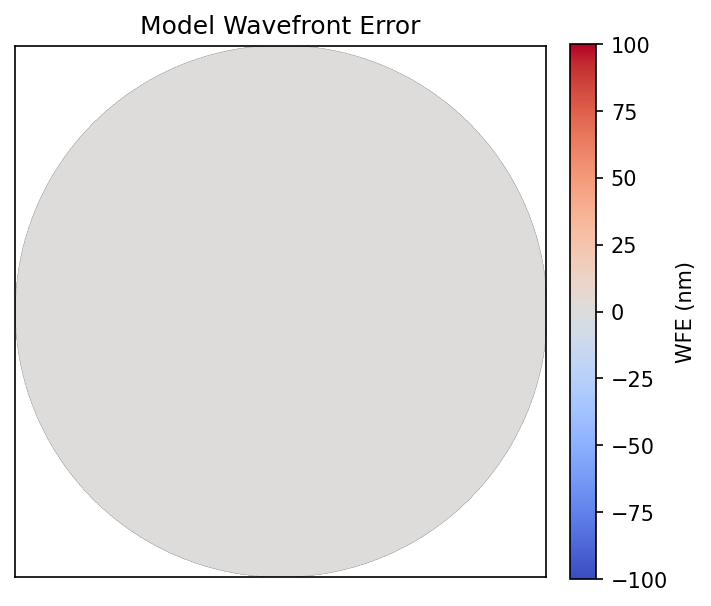

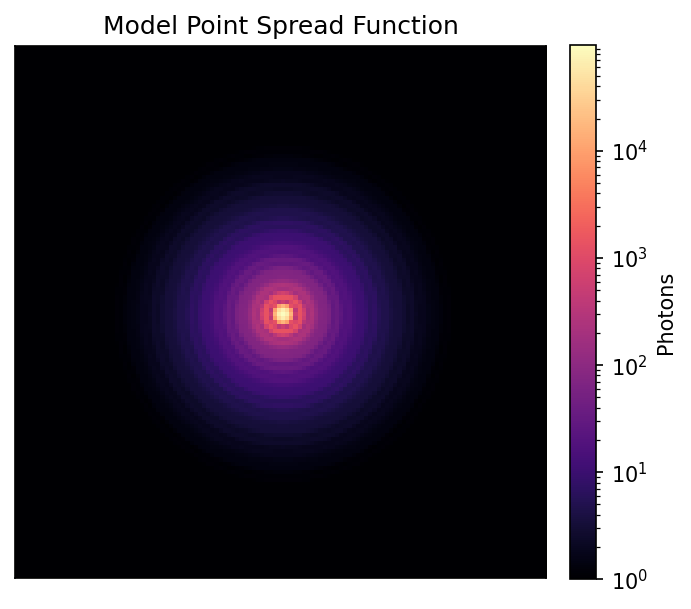

In [44]:
pdpr_model = PDPR(wvls=wvls, amp=pupil, modes=zernikes, coeffs=np.zeros(len(zernikes)), map=np.zeros((npix, npix)), divs=divs, efl=efl, psfs=psfs, 
                  pupil_dx=pupil_dx, focal_dx=focal_dx, masks=[np.ones((fov, fov)).astype('bool') for _ in range(3)], error=gain_invariant_error)


data = copy.copy(pdpr_model.opd)
data[~pupil] = np.nan

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(data.get(), vmin=-100, vmax=100, cmap='coolwarm')
plt.colorbar(pad=0.04, fraction=0.046, label='WFE (nm)')
plt.title('Model Wavefront Error')
plt.xticks([])
plt.yticks([])

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(pdpr_model.models[1].I.get(), norm='log', cmap='magma', vmin=1)
plt.colorbar(pad=0.04, fraction=0.046, label='Photons')   
plt.xticks([])
plt.yticks([])
plt.title('Model Point Spread Function') 

Text(0.5, 1.0, 'difference: 16.4 nm RMS')

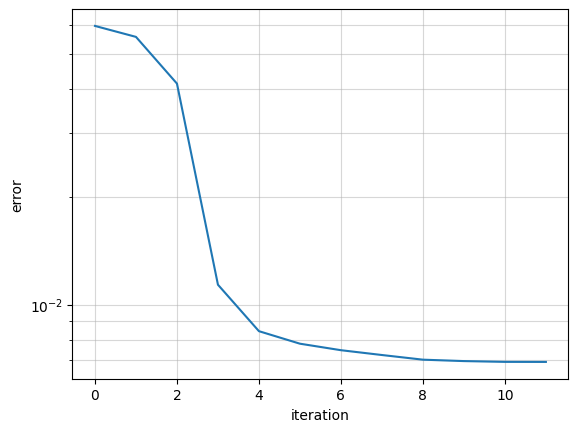

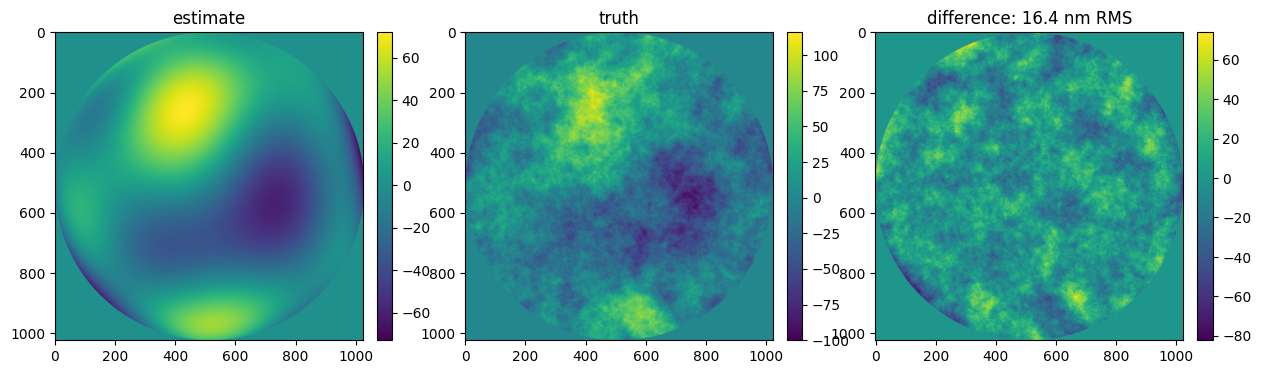

In [45]:
pdpr_fg = partial(pdpr_model.fg, opt_param='coeffs', opt_weights=np.ones(len(zernikes)))
minimize(pdpr_fg, x0=np.zeros(len(zernikes)).get(), jac=True, method='L-BFGS-B', 
         options={'maxls' : 10, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : 10})

plt.figure()
plt.semilogy(np.array(pdpr_model.costs).get())
plt.xlabel('iteration')
plt.ylabel('error')
plt.grid(which='both', alpha=0.5)

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(pdpr_model.opd.get() * pupil.get())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('estimate')
plt.subplot(132)
plt.imshow(opd_truth.get() * pupil.get())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('truth')
diff = pdpr_model.opd - opd_truth
plt.subplot(133)
plt.imshow(diff.get() * pupil.get())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title(f'difference: {np.sqrt(np.mean(diff[pupil] ** 2)):.1f} nm RMS')

Text(0.5, 1.0, 'Model Point Spread Function')

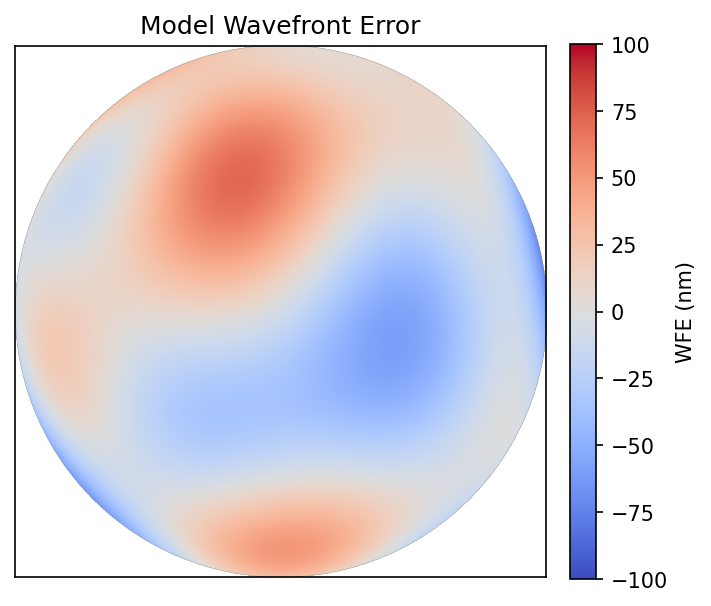

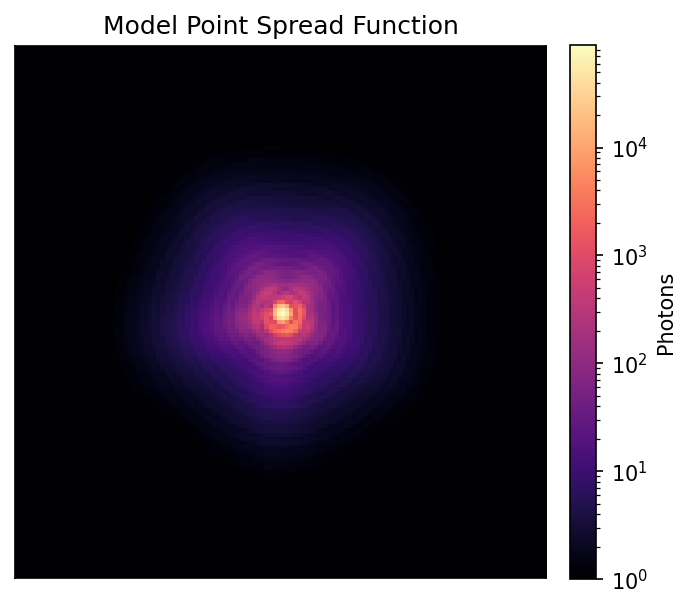

In [46]:
data = copy.copy(pdpr_model.opd)
data[~pupil] = np.nan

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(data.get(), vmin=-100, vmax=100, cmap='coolwarm')
plt.colorbar(pad=0.04, fraction=0.046, label='WFE (nm)')
plt.title('Model Wavefront Error')
plt.xticks([])
plt.yticks([])

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(pdpr_model.models[1].I.get(), norm='log', cmap='magma', vmin=1)
plt.colorbar(pad=0.04, fraction=0.046, label='Photons')   
plt.xticks([])
plt.yticks([])
plt.title('Model Point Spread Function') 

Text(0.5, 1.0, 'difference: 8.5 nm RMS')

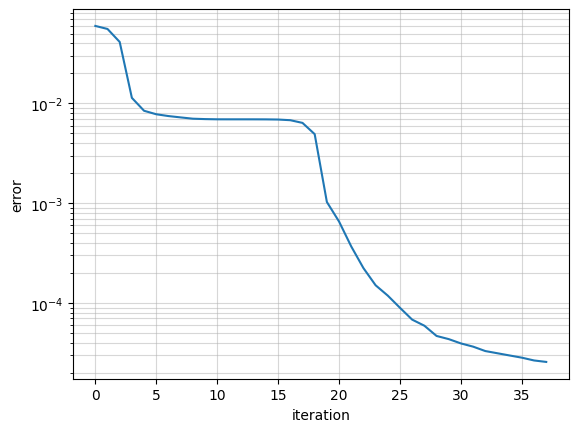

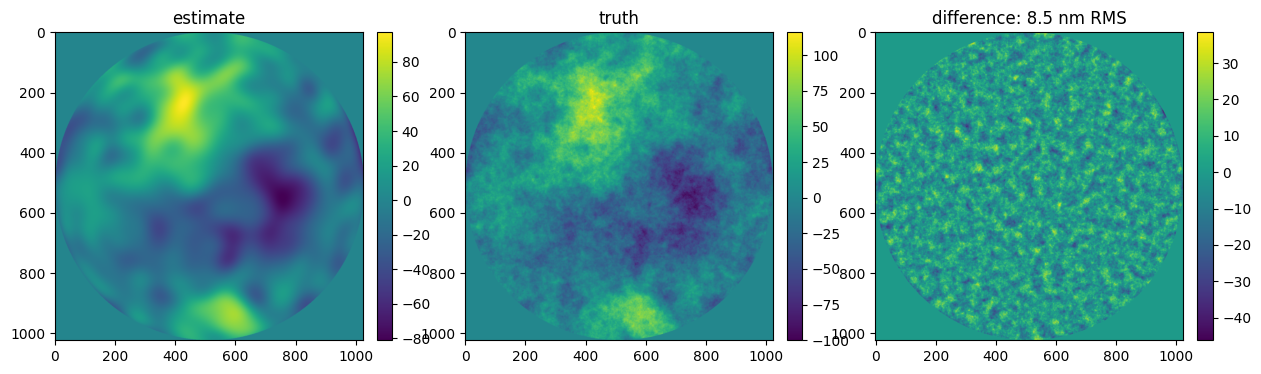

In [47]:
pdpr_fg = partial(pdpr_model.fg, opt_param='map', opt_weights=pupil.ravel())
result = minimize(pdpr_fg, x0=np.zeros_like(opd_truth).ravel().get(), jac=True, method='L-BFGS-B', 
                  options={'maxls' : 10, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : 20})

plt.figure()
plt.semilogy(np.array(pdpr_model.costs).get())
plt.xlabel('iteration')
plt.ylabel('error')
plt.grid(which='both', alpha=0.5)

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(pdpr_model.opd.get() * pupil.get())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('estimate')
plt.subplot(132)
plt.imshow(opd_truth.get() * pupil.get())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('truth')
diff = pdpr_model.opd - opd_truth
plt.subplot(133)
plt.imshow(diff.get() * pupil.get())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title(f'difference: {np.sqrt(np.mean(diff[pupil] ** 2)):.1f} nm RMS')

Text(0.5, 1.0, 'Model Point Spread Function')

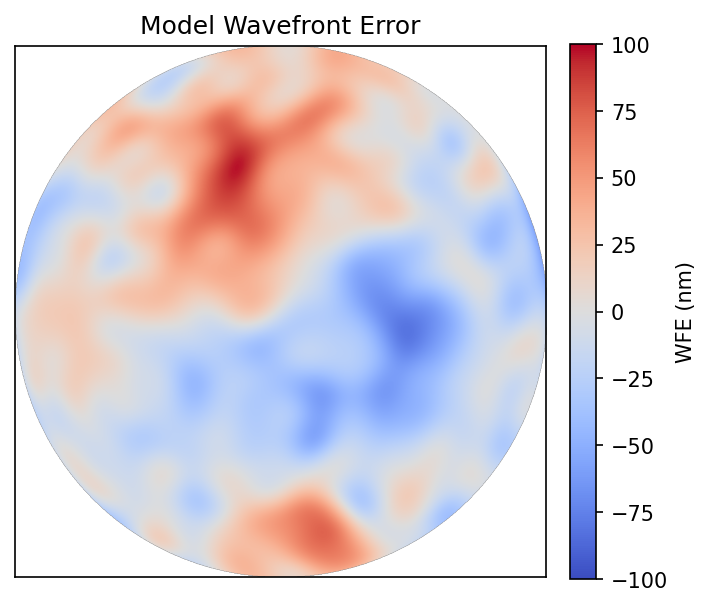

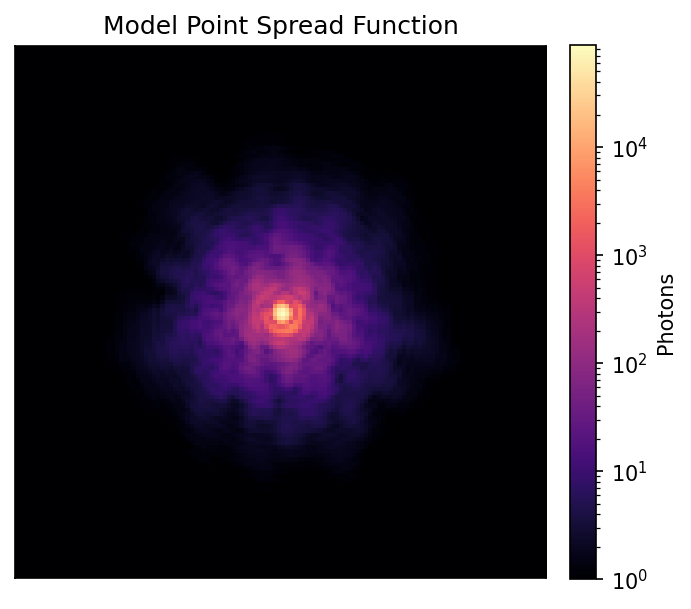

In [48]:
data = copy.copy(pdpr_model.opd)
data[~pupil] = np.nan

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(data.get(), vmin=-100, vmax=100, cmap='coolwarm')
plt.colorbar(pad=0.04, fraction=0.046, label='WFE (nm)')
plt.title('Model Wavefront Error')
plt.xticks([])
plt.yticks([])

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(pdpr_model.models[1].I.get(), norm='log', cmap='magma', vmin=1)
plt.colorbar(pad=0.04, fraction=0.046, label='Photons')   
plt.xticks([])
plt.yticks([])
plt.title('Model Point Spread Function') 